In [10]:
import numpy as np
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

### Convert Multiline FASTA to Single-line FASTA Format

Many FASTA files are written in fixed-width format, where sequences span multiple lines. This can make searching for subsequences inconvenient. In this section, we convert a multiline FASTA file into a single-line FASTA format where each sequence is written on a single line after its header

### Convert and Save Single-line FASTA File
This code reads the original multiline FASTA file and writes a new FASTA file with sequences in single lines.

In [11]:
def convert_to_single_line_fasta(input_file, output_file):
    with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
        sequence_parts = []
        for line in infile:
            line = line.strip()
            if line.startswith('>'):
                if sequence_parts:
                    outfile.write(''.join(sequence_parts) + '\n')
                    sequence_parts = []
                outfile.write(line + '\n')
            else:
                sequence_parts.append(line)
        if sequence_parts:
            outfile.write(''.join(sequence_parts) + '\n')

convert_to_single_line_fasta("multiline_input.fasta", "singleline_input.fasta")

#Markov Transition Matrix Construction

### Steps for constructing markov chain:
1. Convert a multiline FASTA file to single-line format
2. Conatenate sequences
3. Build a first-order Markov transition matrix based on the concatenated sequence
4. Display the matrix


### Load and Prepare the Sequence
Now we read the cleaned FASTA file and extract sequences (skipping headers) into one long DNA sequence.

In [12]:
fasta_file = "singleline_input.fasta"
sequences = []

with open(fasta_file, 'r') as file:
    for line in file:
        line = line.strip()
        if not line.startswith('>'):
            sequences.append(line)

full_sequence = ''.join(sequences)

### Count Dinucleotide Transitions
We iterate through the sequence and count each dinucleotide (e.g., AA, AT, CG, etc.) to form the basis of our transition matrix.

In [13]:
nucleotides = ['A', 'C', 'G', 'T']
transition_counts = defaultdict(lambda: defaultdict(int))

for i in range(len(full_sequence) - 1):
    a = full_sequence[i]
    b = full_sequence[i+1]
    if a in nucleotides and b in nucleotides:
        transition_counts[a][b] += 1


### Normalize to Build the Transition Matrix
Here we convert the raw counts into probabilities to form a proper Markov transition matrix.

In [14]:
transition_matrix = pd.DataFrame(index=nucleotides, columns=nucleotides)

for a in nucleotides:
    total = sum(transition_counts[a].values())
    for b in nucleotides:
        if total > 0:
            transition_matrix.loc[a, b] = transition_counts[a][b] / total
        else:
            transition_matrix.loc[a, b] = 0.0

transition_matrix = transition_matrix.astype(float)

### Visualize with Heatmap
We use seaborn to visualize the transition probabilities as a heatmap.

Markov Transition Matrix (First Order):


,A,C,G,T
A,0.250870,0.242645,0.264790,0.241696
C,0.246548,0.254438,0.244905,0.254109
G,0.251826,0.247380,0.255637,0.245157
T,0.270936,0.237438,0.250246,0.241379


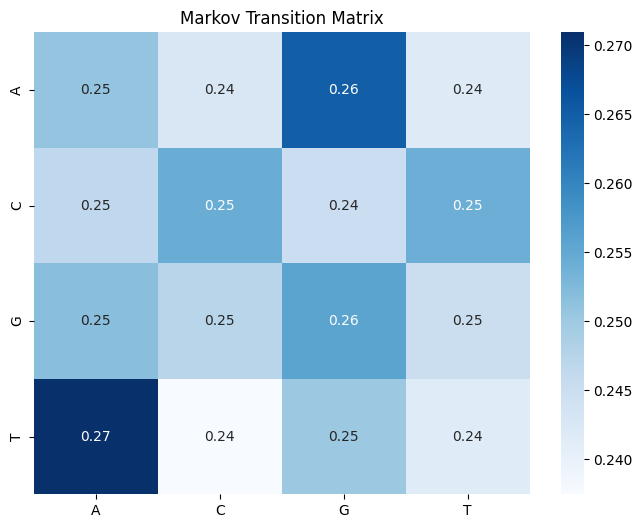

In [15]:
print("Markov Transition Matrix (First Order):")
display(transition_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(transition_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Markov Transition Matrix")
plt.show()